# Construct a hard-masked, island-inpainted global ERA5 + SCOTIA forcing dataset

This notebook is an experimental variant of `construct_forcing_dataset_island_inpainted.ipynb`. It preserves the canonical forcing contract, physical constants, and GEBCO-assisted island repair, but removes the smooth outer-wall taper.

GEBCO is aggregated onto each native $0.25^\circ$ ERA5 cell to identify internal land that the reduced model does not resolve. Both ERA5 stress components are extended across those holes with a bounded Gaussian average of nearby ocean donors **before** anomalies and Ekman conversion. The final vector Ekman transport is finite throughout the binary reduced-model ocean envelope and is exactly `NaN` everywhere outside it.

This ordering is deliberate: setting island stress or Ekman pumping to zero would create another sharp internal edge. A bounded Gaussian interpolation instead averages nearby ocean stress with positive weights, making the forcing consistent with a reduced geometry that treats each basin branch as zonally uninterrupted while guaranteeing that the fill cannot overshoot its donors. The hard outer mask is deliberately *not* smoothed, so this dataset isolates the numerical consequences of tapering from the island correction.

The exported dataset contains the same three variables as the canonical forcing:

- `M_Ek_x(time, latitude, longitude)` in $\mathrm{m^2\,s^{-1}}$;
- `M_Ek_y(time, latitude, longitude)` in $\mathrm{m^2\,s^{-1}}$; and
- `T_N(time)` in $\mathrm{m^3\,s^{-1}}$.

The native ERA5 grid is retained. Generated data are written beneath `data/untracked/forcing/`; the canonical and smoothly tapered forcing products are not overwritten.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("KMP_WARNINGS", "0")

import dask
import dask.array as da
from dask import delayed
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
from netCDF4 import Dataset as NetCDFDataset
import numpy as np
from scipy import ndimage, optimize
import xarray as xr

REPO_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").exists()
)
DATA_ROOT = REPO_ROOT / "data" / "untracked"
ISOBATH_PATH = REPO_ROOT / "data" / "tracked" / "isobath" / "global_isobath_GEBCO_1000m.nc"
GEBCO_PATH = DATA_ROOT / "GEBCO" / "GEBCO_2026_sub_ice" / "GEBCO_2026_sub_ice.nc"
WINDS_PATH = DATA_ROOT / "ERA5" / "global_winds.nc"
SCOTIA_PATH = DATA_ROOT / "SCOTIA" / "SCOTIA_overturning_diagnostics.nc"
OUTPUT_PATH = DATA_ROOT / "forcing" / "global_ERA5_SCOTIA_forcing_island_inpainted_no_taper.nc"

for path in (ISOBATH_PATH, GEBCO_PATH, WINDS_PATH, SCOTIA_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Required input does not exist: {path}")

print(f"Repository: {REPO_ROOT}")
print(f"Output:     {OUTPUT_PATH}")

Repository: /private/tmp/MOCAdjustmentTheory-inpainting-fix
Output:     /private/tmp/MOCAdjustmentTheory-inpainting-fix/data/untracked/forcing/global_ERA5_SCOTIA_forcing_island_inpainted_no_taper.nc


## Physical and numerical choices

The physical constants, equatorial regularization, and native grid match the canonical forcing notebook. No taper is applied. Two native-grid rows are retained beyond the northernmost model section so centred spatial differences have an ocean-valued halo where the geometry is open.

GEBCO land presence is aggregated over the complete footprint of every ERA5 cell, rather than sampled only at its centre, so small islands are retained. Land components near the outer envelope are classified as coastline rather than islands. The inpainting mask includes a configurable four-cell (one-degree) halo around each retained island, while a one-cell ocean ring is preserved around every inpainting component to provide finite Dirichlet values.

In [2]:
EARTH_ROTATION_RATE = 7.292115e-5  # rad s-1
EARTH_RADIUS = 6.371e6             # m
RHO_0 = 1027.0                     # kg m-3; upstream conversion choice
G_PRIME = 0.02                     # m s-2; sets the capped wave speed
ATLANTIC_NORTH = 55.0              # degrees north
ISLAND_HALO_CELLS = 4              # one-degree ERA5 coastal-transition buffer
INPAINT_SIGMA_CELLS = 4.0          # one-degree Gaussian donor weighting
BOUNDARY_HALO_CELLS = 2            # open-boundary rows for centred differences
GRID_SPACING_DEGREES = 0.25        # native ERA5 grid used by this experiment
ERA5_WRAP_START = 280.0            # 280..360 becomes -80..0
ERA5_EAST_LIMIT = 290.0


def coriolis(latitude):
    """Coriolis parameter in inverse seconds."""
    return 2.0 * EARTH_ROTATION_RATE * np.sin(np.deg2rad(latitude))


def beta(latitude):
    """Meridional Coriolis gradient in inverse metres per second."""
    return (
        2.0
        * EARTH_ROTATION_RATE
        * np.cos(np.deg2rad(latitude))
        / EARTH_RADIUS
    )


def cap_latitude(g_prime, depth):
    """Latitude where the long Rossby speed reaches its gravity-wave cap."""
    gravity_wave_cap = np.sqrt(g_prime * depth) / 3.0
    return float(
        optimize.brentq(
            lambda latitude: (
                beta(latitude) * g_prime * depth / coriolis(latitude) ** 2
                - gravity_wave_cap
            ),
            1.0,
            30.0,
        )
    )


def common_latitude_domain(dataset, *boundary_names):
    """Latitude interval on which every named boundary is finite."""
    valid = [dataset[name].dropna("latitude") for name in boundary_names]
    south = max(float(boundary.latitude[0]) for boundary in valid)
    north = min(float(boundary.latitude[-1]) for boundary in valid)
    if south >= north:
        raise ValueError(f"No common domain for {boundary_names}")
    return south, north

## Geometry and active latitude ranges

The five-region topology is represented on each latitude by one or more disjoint ocean intervals. South of the Pacific entrance there is one Atlantic-to-Pacific interval; between the Pacific and Indian entrances there is an Atlantic-to-Indian interval plus the Pacific; farther north there are separate Atlantic, Indian, and Pacific intervals.

In [3]:
isobath = xr.open_dataset(ISOBATH_PATH).dropna("latitude", how="all")
required_boundaries = {"x_wP", "x_wA", "x_wI", "x_eP", "x_eA", "x_eI"}
if set(isobath.data_vars) != required_boundaries:
    raise ValueError("Isobath dataset does not match the six-variable specification")

H = float(isobath.attrs["isobath_depth_m"])
y_S, _ = common_latitude_domain(isobath, "x_wA", "x_eP")
y_I, y_NI = common_latitude_domain(isobath, "x_wI", "x_eI")
y_P, y_NP = common_latitude_domain(isobath, "x_wP", "x_eP")
y_P = max(y_P, y_S)
_, y_NA_supported = common_latitude_domain(isobath, "x_wA", "x_eA")
global_north = (
    max(ATLANTIC_NORTH, y_NI, y_NP)
    + BOUNDARY_HALO_CELLS * GRID_SPACING_DEGREES
)
if global_north > y_NA_supported:
    raise ValueError("Atlantic geometry does not support the northern differencing halo")

phi_c = cap_latitude(G_PRIME, H)
gamma = float(coriolis(phi_c))
print(
    f"forcing domain: {y_S:.3f} to {global_north:.3f} deg; "
    f"T_N latitude {ATLANTIC_NORTH:.3f} deg; "
    f"Pacific entrance {y_P:.3f} deg; Indian entrance {y_I:.3f} deg; "
    f"Pacific/Indian north {y_NP:.3f}/{y_NI:.3f} deg"
)
print(f"H={H:g} m; cap latitude={phi_c:.3f} deg; gamma={gamma:.6e} s-1")

forcing domain: -55.075 to 59.858 deg; T_N latitude 55.000 deg; Pacific entrance -43.992 deg; Indian entrance -34.992 deg; Pacific/Indian north 59.358/24.658 deg
H=1000 m; cap latitude=6.877 deg; gamma=1.746177e-05 s-1


## Common monthly anomalies

SCOTIA timestamps are shifted from the monthly midpoint to the first day, matching ERA5 after its six-hour timestamp correction. Means are removed over their exact common record before any physical conversion.

In [4]:
scotia = xr.open_dataset(SCOTIA_PATH, chunks={}).moc
scotia = scotia.assign_coords(time=scotia.time - np.timedelta64(14, "D"))
scotia = scotia.astype(np.float64)
scotia_anomaly = scotia - scotia.mean("time")

winds_raw = xr.open_dataset(WINDS_PATH, chunks={})[["avg_iews", "avg_inss"]]
winds_raw = winds_raw.drop_vars(["expver", "number"], errors="ignore")
winds_raw = winds_raw.assign_coords(
    valid_time=winds_raw.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")

winds = xr.concat(
    [
        winds_raw.sel(longitude=slice(ERA5_WRAP_START, None)).assign_coords(
            longitude=lambda dataset: dataset.longitude - 360.0
        ),
        winds_raw.sel(longitude=slice(0.0, ERA5_EAST_LIMIT)),
    ],
    dim="longitude",
).sortby("longitude")
winds = winds.sel(latitude=slice(global_north, y_S)).sortby("latitude")
winds = winds.sel(time=scotia.time)
if not winds.time.equals(scotia.time):
    raise ValueError("ERA5 and SCOTIA do not share an exact monthly time grid")
winds = winds.chunk({"time": 12, "latitude": 32, "longitude": 128})

latitude = winds.latitude.values.astype(float)
longitude = winds.longitude.values.astype(float)
print(winds.sizes)

Frozen({'time': 246, 'latitude': 460, 'longitude': 1481})


## Binary reduced-model ocean envelope

The five topological intervals define a single binary ocean envelope on the native forcing grid. Cells strictly between the interpolated western and eastern 1000 m isobaths are ocean; all other cells are outside the reduced-model domain. Unlike the canonical construction, no distance transform or smooth ramp is applied. The Indian and Pacific close at their northern geometry limits, while the Atlantic remains ocean-valued through the small northern differencing halo.

In [5]:
boundary = isobath.interp(latitude=latitude)
active_layer = np.zeros((latitude.size, longitude.size), dtype=bool)


def include_interval(rows, west_name, east_name):
    """Add one latitude-dependent isobath interval to the active layer."""
    west = boundary[west_name].values
    east = boundary[east_name].values
    valid = rows & np.isfinite(west) & np.isfinite(east)
    active_layer[valid] |= (
        (longitude[None, :] > west[valid, None])
        & (longitude[None, :] < east[valid, None])
    )


def ceiling_latitude(value):
    """Return the first forcing latitude at or north of a boundary."""
    candidates = latitude[latitude >= value]
    if candidates.size == 0:
        raise ValueError("The forcing grid does not cover the active domain")
    return candidates[0]


# Match the model's convention: transition latitudes are snapped northward
# once and shared by adjacent regions. The union must include both branches
# on those rows so every regional solve has finite forcing at its edge.
grid_y_S = ceiling_latitude(y_S)
grid_y_P = ceiling_latitude(y_P)
grid_y_I = ceiling_latitude(y_I)
include_interval((latitude >= grid_y_S) & (latitude <= grid_y_P), "x_wA", "x_eP")
include_interval((latitude >= grid_y_P) & (latitude <= grid_y_I), "x_wA", "x_eI")
include_interval(latitude >= grid_y_I, "x_wA", "x_eA")
include_interval((latitude >= grid_y_I) & (latitude <= y_NI), "x_wI", "x_eI")
include_interval((latitude >= grid_y_P) & (latitude <= y_NP), "x_wP", "x_eP")

latitude_step = float(np.diff(latitude).min())
longitude_step = float(np.diff(longitude).min())
if not np.allclose(np.diff(latitude), latitude_step) or not np.allclose(
    np.diff(longitude), longitude_step
):
    raise ValueError("The ocean mask requires a uniform latitude-longitude grid")
if not np.isclose(latitude_step, GRID_SPACING_DEGREES):
    raise ValueError("The forcing latitude spacing is not the expected ERA5 spacing")

ocean_mask = xr.DataArray(
    active_layer,
    dims=("latitude", "longitude"),
    coords={"latitude": latitude, "longitude": longitude},
    name="ocean_mask",
    attrs={
        "long_name": "binary reduced-model ocean envelope",
        "inside_value": True,
        "outside_value": False,
    },
)
if not bool(ocean_mask.any()) or bool(ocean_mask.all()):
    raise AssertionError("Ocean mask must contain both ocean and exterior cells")
north_of_t_n = np.flatnonzero(latitude > ATLANTIC_NORTH)[0]
atlantic_interior = (
    (longitude > boundary.x_wA.values[north_of_t_n])
    & (longitude < boundary.x_eA.values[north_of_t_n])
)
if not np.all(active_layer[north_of_t_n, atlantic_interior]):
    raise AssertionError("Atlantic ocean mask does not extend north of T_N")
ocean_mask

<xarray.DataArray 'ocean_mask' (latitude: 460, longitude: 1481)> Size: 681kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(460, 1481))
Coordinates:
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Attributes:
    long_name:      binary reduced-model ocean envelope
    inside_value:   True
    outside_value:  False

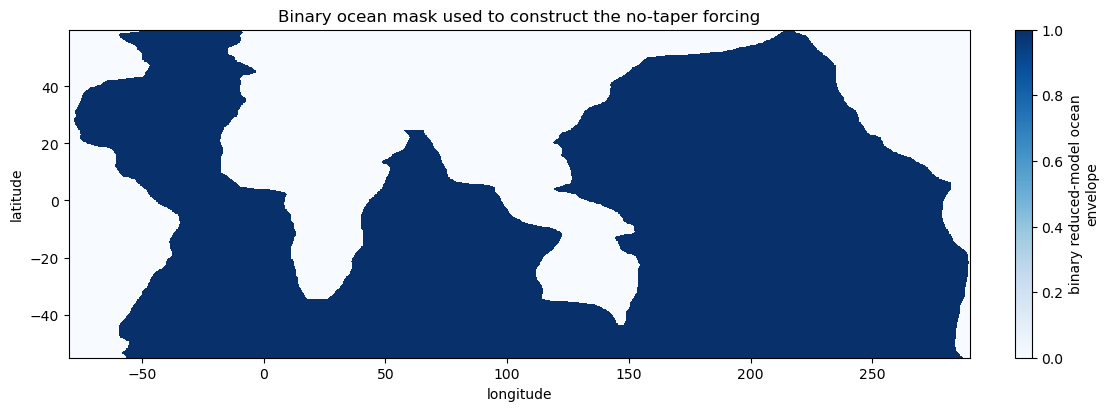

In [6]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ocean_mask.astype(np.int8).plot.pcolormesh(
    ax=ax, x="longitude", y="latitude", cmap="Blues", vmin=0, vmax=1
)
ax.set_title("Binary ocean mask used to construct the no-taper forcing")
plt.show()

## Identify internal islands with GEBCO

The six single-valued isobath functions describe the outer walls of the reduced model but deliberately omit islands. GEBCO is therefore used only to find land embedded inside that binary ocean envelope.

For every ERA5 cell, the high-resolution source is reduced to whether the cell contains any land. Reading GEBCO one ERA5 latitude band at a time keeps peak memory small despite the native 15 arc-second grid.

Connected land components that enter a guard band along the ocean-envelope boundary are classified as coastline and excluded. The remaining internal components seed a four-cell inpainting halo. The halo is clipped to an eroded ocean mask, and only finite ocean cells outside that mask may donate stress to the bounded interpolation.

In [7]:
def gebco_presence_on_grid(path, target_latitude, target_longitude):
    """Return ERA5-cell land presence aggregated from native GEBCO.

    Each target cell is represented by all GEBCO samples in its rectangular
    footprint. Longitude windows wrap periodically so the unwrapped model grid
    can include both negative Atlantic and greater-than-180 Pacific values.
    """
    latitude_step = float(np.diff(target_latitude).min())
    longitude_step = float(np.diff(target_longitude).min())
    land = np.zeros((target_latitude.size, target_longitude.size), dtype=bool)

    with NetCDFDataset(path) as source:
        source_latitude = np.asarray(source.variables["lat"][:], dtype=float)
        source_longitude = np.asarray(source.variables["lon"][:], dtype=float)
        elevation = source.variables["elevation"]
        extended_longitude = np.concatenate(
            (source_longitude - 360.0, source_longitude, source_longitude + 360.0)
        )
        source_longitude_size = source_longitude.size
        wrapped_target = (target_longitude + 180.0) % 360.0 - 180.0
        longitude_windows = []
        for value in wrapped_target:
            lower = np.searchsorted(
                extended_longitude, value - longitude_step / 2.0, side="left"
            )
            upper = np.searchsorted(
                extended_longitude, value + longitude_step / 2.0, side="left"
            )
            longitude_windows.append(
                np.arange(lower, upper, dtype=int) % source_longitude_size
            )
        window_sizes = {window.size for window in longitude_windows}
        if len(window_sizes) != 1:
            raise RuntimeError("GEBCO longitude aggregation windows are inconsistent")
        longitude_windows = np.stack(longitude_windows)

        for row, value in enumerate(target_latitude):
            lower = np.searchsorted(
                source_latitude, value - latitude_step / 2.0, side="left"
            )
            upper = np.searchsorted(
                source_latitude, value + latitude_step / 2.0, side="left"
            )
            band = np.asarray(elevation[lower:upper, :])
            if band.size == 0:
                raise RuntimeError(f"GEBCO does not cover latitude {value}")
            land_by_longitude = np.any(band >= 0.0, axis=0)
            land[row] = land_by_longitude[longitude_windows].any(axis=1)

    return land


land_presence = gebco_presence_on_grid(
    GEBCO_PATH, latitude, longitude
)
eight_connected = np.ones((3, 3), dtype=bool)
cardinal_connected = np.array(
    [[False, True, False], [True, True, True], [False, True, False]]
)
land_inside_ocean = land_presence & active_layer
land_labels, land_component_count = ndimage.label(
    land_inside_ocean, structure=eight_connected
)
boundary_guard = active_layer & ~ndimage.binary_erosion(
    active_layer,
    structure=eight_connected,
    iterations=ISLAND_HALO_CELLS + 1,
    border_value=0,
)
coastal_labels = np.unique(land_labels[boundary_guard & (land_labels > 0)])
internal_land = land_inside_ocean & ~np.isin(land_labels, coastal_labels)
ocean_interior = ndimage.binary_erosion(
    active_layer, structure=cardinal_connected, iterations=1, border_value=0
)
island_mask = (
    ndimage.binary_dilation(
        internal_land,
        structure=eight_connected,
        iterations=ISLAND_HALO_CELLS,
    )
    & ocean_interior
)

if np.any(island_mask & ~active_layer):
    raise AssertionError("Island inpainting mask extends outside the active layer")
if np.any(internal_land & ~island_mask):
    raise AssertionError("An internal island was clipped from the inpainting mask")
if np.any(ndimage.binary_dilation(island_mask, structure=cardinal_connected) & ~active_layer):
    raise AssertionError("Island inpainting lacks a finite ocean boundary ring")

_, island_component_count = ndimage.label(
    island_mask, structure=eight_connected
)
print(
    f"inpainting {island_mask.sum():,} ERA5 cells in "
    f"{island_component_count:,} internal components; "
    f"excluded {coastal_labels.size:,} boundary-connected components"
)

inpainting 32,421 ERA5 cells in 99 internal components; excluded 131 boundary-connected components


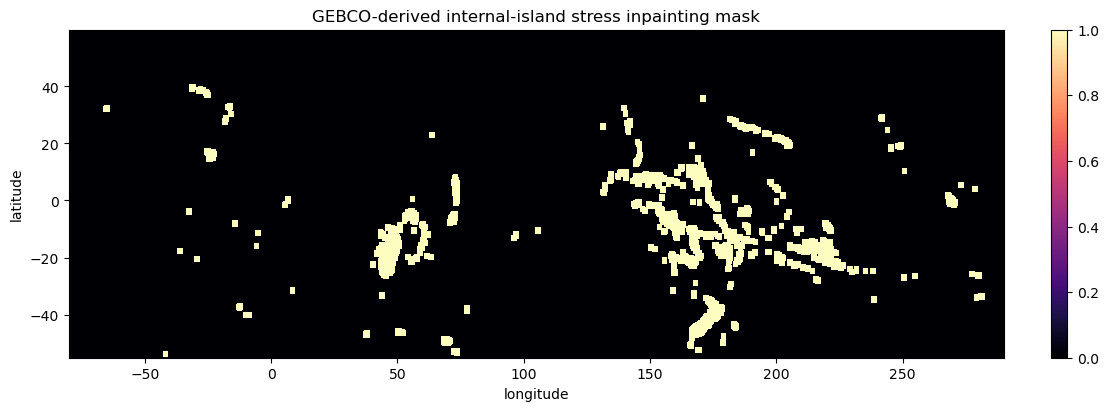

In [8]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
xr.DataArray(
    island_mask,
    dims=("latitude", "longitude"),
    coords={"latitude": latitude, "longitude": longitude},
).plot.pcolormesh(ax=ax, x="longitude", y="latitude", cmap="magma")
ax.set_title("GEBCO-derived internal-island stress inpainting mask")
plt.show()

## Bounded Gaussian extension of ERA5 stress

Each missing island or halo cell receives a positive-weight Gaussian average of nearby finite ocean stress. Normalisation makes every fill a convex combination of donors, so it cannot create the extreme overshoots possible in the previous sparse solve.

The static donor weights are precomputed once. Dask then evaluates twelve months and both stress components in each task, retaining original ERA5 values bit-for-bit outside the mask and keeping the full preprocessing lazy through export.

In [9]:
def gaussian_inpainting_weights(mask, donor_mask, sigma_cells):
    """Return a finite normalisation field and sufficient filter radius."""
    if mask.ndim != 2 or donor_mask.shape != mask.shape or not np.any(mask):
        raise ValueError("mask and donor_mask must be matching two-dimensional arrays")
    if np.any(mask & donor_mask) or not np.any(donor_mask):
        raise ValueError("donors must be non-empty and outside the inpainting mask")
    if not np.isfinite(sigma_cells) or sigma_cells <= 0.0:
        raise ValueError("sigma_cells must be positive")

    maximum_distance = float(
        ndimage.distance_transform_edt(~donor_mask)[mask].max()
    )
    radius = int(np.ceil(maximum_distance)) + ISLAND_HALO_CELLS
    denominator = ndimage.gaussian_filter(
        donor_mask.astype(np.float64),
        sigma=sigma_cells,
        radius=radius,
        mode="constant",
        cval=0.0,
    )
    if np.any(denominator[mask] <= np.finfo(np.float64).tiny):
        raise ValueError("Gaussian support does not reach every inpainting cell")
    return denominator, radius


def inpaint_stress_block(
    values,
    mask,
    donor_mask,
    denominator,
    sigma_cells,
    radius,
):
    """Fill one vector-stress block with bounded Gaussian donor averages."""
    if values.ndim != 4 or values.shape[-2:] != mask.shape:
        raise ValueError("stress block must have time, component, and mask dimensions")
    donor_values = values[..., donor_mask]
    if not np.all(np.isfinite(donor_values)):
        raise ValueError("ocean stress donors must be finite")

    numerator = ndimage.gaussian_filter(
        np.where(donor_mask[None, None, :, :], values, 0.0),
        sigma=sigma_cells,
        radius=radius,
        axes=(-2, -1),
        mode="constant",
        cval=0.0,
    )
    interpolated = np.zeros_like(numerator)
    np.divide(
        numerator,
        denominator[None, None, :, :],
        out=interpolated,
        where=denominator[None, None, :, :] > np.finfo(np.float64).tiny,
    )
    filled_values = interpolated[..., mask]
    donor_minimum = donor_values.min(axis=-1)[..., None]
    donor_maximum = donor_values.max(axis=-1)[..., None]
    tolerance = 16.0 * np.finfo(values.dtype).eps * np.maximum(
        1.0, np.maximum(abs(donor_minimum), abs(donor_maximum))
    )
    if (
        not np.all(np.isfinite(filled_values))
        or np.any(filled_values < donor_minimum - tolerance)
        or np.any(filled_values > donor_maximum + tolerance)
    ):
        raise RuntimeError("bounded island interpolation violated donor extrema")

    output = values.copy()
    output[..., mask] = filled_values.astype(values.dtype, copy=False)
    return output


def lazy_inpainted_stress(values, mask, donor_mask, time_chunk=12):
    """Return a lazy bounded interpolation of vector stress over islands."""
    denominator, radius = gaussian_inpainting_weights(
        mask, donor_mask, INPAINT_SIGMA_CELLS
    )
    rechunked = values.rechunk(
        {0: time_chunk, 1: -1, 2: -1, 3: -1}
    )
    delayed_blocks = rechunked.to_delayed().reshape(
        len(rechunked.chunks[0]), 1, 1, 1
    )[:, 0, 0, 0]
    output_blocks = []
    for block, count in zip(delayed_blocks, rechunked.chunks[0]):
        filled = delayed(inpaint_stress_block)(
            block,
            mask,
            donor_mask,
            denominator,
            INPAINT_SIGMA_CELLS,
            radius,
        )
        output_blocks.append(
            da.from_delayed(
                filled,
                shape=(count, values.shape[1], values.shape[2], values.shape[3]),
                dtype=values.dtype,
            )
        )
    return da.concatenate(output_blocks, axis=0)


stress = da.stack(
    (
        winds.avg_iews.transpose("time", "latitude", "longitude").data,
        winds.avg_inss.transpose("time", "latitude", "longitude").data,
    ),
    axis=1,
)
stress_donor_mask = active_layer & ~land_presence & ~island_mask
inpainted_stress = lazy_inpainted_stress(
    stress, island_mask, stress_donor_mask
)
winds_inpainted = xr.Dataset(
    {
        "avg_iews": (
            ("time", "latitude", "longitude"), inpainted_stress[:, 0]
        ),
        "avg_inss": (
            ("time", "latitude", "longitude"), inpainted_stress[:, 1]
        ),
    },
    coords={
        "time": winds.time,
        "latitude": winds.latitude,
        "longitude": winds.longitude,
    },
)
# Accumulate the climatology in float64.  A float32 Dask reduction over
# 246 oppositely signed monthly values can otherwise leave a spurious
# O(1e-3 m2 s-1) transport mean through cancellation alone.
winds_inpainted_float64 = winds_inpainted.astype(np.float64)
winds_anomaly = winds_inpainted_float64 - winds_inpainted_float64.mean("time")
winds_anomaly

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 246, latitude: 460, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    avg_iews   (time, latitude, longitude) float64 1GB dask.array<chunksize=(12, 460, 1481), meta=np.ndarray>
    avg_inss   (time, latitude, longitude) float64 1GB dask.array<chunksize=(12, 460, 1481), meta=np.ndarray>

## Convert stress to hard-masked vector Ekman transport

No amplitude taper is applied. The inpainted stress anomaly is converted directly and then masked to `NaN` outside the binary ocean envelope. With eastward stress $\tau_x$ and northward stress $\tau_y$,

$$M_{\mathrm{Ek},x}=\frac{I_\gamma\tau_y}{\rho_0},\qquad M_{\mathrm{Ek},y}=-\frac{I_\gamma\tau_x}{\rho_0}.$$

The model can therefore derive both $w_{\mathrm{Ek}}=\nabla\cdot\mathbf M_{\mathrm{Ek}}$ and every Ekman section transport from the same two fields. Internal islands remain finite because they were inpainted; only the exterior of the reduced-model ocean is missing.

In [10]:
inverse_f = coriolis(winds_anomaly.latitude) / (
    coriolis(winds_anomaly.latitude) ** 2 + gamma**2
)
tau_x = winds_anomaly.avg_iews.where(ocean_mask)
tau_y = winds_anomaly.avg_inss.where(ocean_mask)

M_Ek_x_raw = tau_y * inverse_f / RHO_0
M_Ek_y_raw = -tau_x * inverse_f / RHO_0
M_Ek_x = (
    M_Ek_x_raw - M_Ek_x_raw.mean("time", skipna=True)
).astype(np.float32).rename("M_Ek_x")
M_Ek_y = (
    M_Ek_y_raw - M_Ek_y_raw.mean("time", skipna=True)
).astype(np.float32).rename("M_Ek_y")
T_N = (scotia_anomaly * 1e6).astype(np.float64).rename("T_N")

M_Ek_x.attrs = {
    "units": "m2 s-1",
    "long_name": "eastward Ekman transport anomaly",
    "positive": "eastward",
}
M_Ek_y.attrs = {
    "units": "m2 s-1",
    "long_name": "northward Ekman transport anomaly",
    "positive": "northward",
}
T_N.attrs = {
    "units": "m3 s-1",
    "long_name": "total northern Atlantic transport anomaly from SCOTIA",
    "positive": "northward",
    "latitude_degrees_north": ATLANTIC_NORTH,
}

forcing = xr.Dataset({"M_Ek_x": M_Ek_x, "M_Ek_y": M_Ek_y, "T_N": T_N})
forcing = forcing.transpose("time", "latitude", "longitude", missing_dims="ignore")
forcing.attrs.update(
    title="Hard-masked global ERA5 Ekman transport and SCOTIA northern forcing anomalies",
    source_wind_stress="ERA5 monthly mean eastward/northward turbulent surface stress",
    source_northern_transport="SCOTIA overturning diagnostics MOC",
    source_geometry=ISOBATH_PATH.name,
    source_bathymetry=GEBCO_PATH.name,
    anomaly_reference="time mean over the common 2004-01 to 2024-06 monthly record",
    rho_0_kg_m3=RHO_0,
    g_prime_m_s2=G_PRIME,
    active_layer_depth_m=H,
    equatorial_cap_latitude_degrees=phi_c,
    equatorial_gamma_s_1=gamma,
    spatial_mask="binary reduced-model ocean envelope; NaN outside; no taper",
    generated_by="notebooks/input_generation/construct_forcing_dataset_island_inpainted_no_taper.ipynb",
    island_preprocessing="bounded Gaussian average of ERA5 ocean stress over GEBCO-resolved internal land before Ekman conversion",
    island_mask_cell_count=int(island_mask.sum()),
    island_mask_component_count=int(island_component_count),
    island_boundary_guard_cells=ISLAND_HALO_CELLS + 1,
    island_halo_cells=ISLAND_HALO_CELLS,
    island_inpainting_sigma_cells=INPAINT_SIGMA_CELLS,
    island_inpainting_sigma_degrees=INPAINT_SIGMA_CELLS * GRID_SPACING_DEGREES,
    northern_differencing_halo_cells=BOUNDARY_HALO_CELLS,
)
forcing

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 460, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 670MB dask.array<chunksize=(12, 460, 1481), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 670MB dask.array<chunksize=(12, 460, 1481), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/21)
    title:                             Hard-masked global ERA5 Ekman transpor...
    source_wind_stress:                ERA5 monthly mean eastward/northward t...
    source_northern_transport:         SCOTIA overturning diagnostics MOC
    source_geometry:                   global_isobath_GEBCO_1000m.nc
    source_bathymetry:                 GEBCO_2026_sub_ice.nc
    anomaly_reference:                 time mean over the common 2004-01 to 2...
    ...                                ...
    island_mask_component_count:       99
    island_boundary_guard_cells:       5
    island_halo_cells:                 4
    island_inpainting_sigma_cells:     4.0
    island_inpainting_sigma_degrees:   1.0
    northern_differencing_halo_cells:  2

## Contract checks and export

The canonical three-variable schema, dimensions, units, coordinates, and temporal anomaly contract are retained. Spatial checks now enforce a different missing-value contract: both Ekman components must be finite at every binary-ocean cell and `NaN` at every exterior cell. Additional checks confirm that the island inpainting retains a finite ocean boundary ring and that the no-taper provenance is recorded.

The result is written to a separate file so the baseline forcing remains available for the comparison notebook.

In [11]:
if set(forcing.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
    raise AssertionError("Forcing dataset must contain exactly three variables")
for name in ("M_Ek_x", "M_Ek_y"):
    if forcing[name].dims != ("time", "latitude", "longitude"):
        raise AssertionError(f"Unexpected dimensions for {name}")
    if forcing[name].attrs["units"] != "m2 s-1":
        raise AssertionError(f"Unexpected units for {name}")
if forcing.T_N.dims != ("time",) or forcing.T_N.attrs["units"] != "m3 s-1":
    raise AssertionError("Unexpected T_N contract")
if forcing.T_N.attrs["latitude_degrees_north"] != ATLANTIC_NORTH:
    raise AssertionError("T_N has the wrong prescribed latitude")
if not forcing.time.equals(scotia.time):
    raise AssertionError("Forcing variables do not use the SCOTIA time grid")
if not np.all(np.diff(forcing.latitude) > 0) or not np.all(np.diff(forcing.longitude) > 0):
    raise AssertionError("Spatial coordinates must be strictly increasing")
if not np.isclose(float(forcing.T_N.mean()), 0.0, atol=1e-8):
    raise AssertionError("T_N is not a zero-mean anomaly")
M_Ek_time_means_and_scales = dask.compute(
    abs(forcing.M_Ek_x.astype(np.float64).mean("time", skipna=True)).max(),
    abs(forcing.M_Ek_y.astype(np.float64).mean("time", skipna=True)).max(),
    abs(forcing.M_Ek_x).max(skipna=True),
    abs(forcing.M_Ek_y).max(skipna=True),
)
M_Ek_time_means = M_Ek_time_means_and_scales[:2]
M_Ek_scale = max(1.0, *map(float, M_Ek_time_means_and_scales[2:]))
M_Ek_mean_tolerance = 16.0 * np.finfo(np.float32).eps * M_Ek_scale
if max(map(float, M_Ek_time_means)) >= M_Ek_mean_tolerance:
    raise AssertionError(f"M_Ek anomaly mean is too large: {M_Ek_time_means}")
transport_limits = xr.Dataset(
    {
        f"{name}_minimum": forcing[name].min(("latitude", "longitude"), skipna=True)
        for name in ("M_Ek_x", "M_Ek_y")
    }
    | {
        f"{name}_maximum": forcing[name].max(("latitude", "longitude"), skipna=True)
        for name in ("M_Ek_x", "M_Ek_y")
    }
).compute()
if not all(np.all(np.isfinite(array)) for array in transport_limits.data_vars.values()):
    raise AssertionError("M_Ek spatial extrema must be finite at every time")
print(transport_limits)

mask_sample = forcing[["M_Ek_x", "M_Ek_y"]].isel(time=[0, -1]).compute()
for name in mask_sample.data_vars:
    values = mask_sample[name].values
    if not np.all(np.isfinite(values[:, active_layer])):
        raise AssertionError(f"{name} contains missing ocean values")
    if not np.all(np.isnan(values[:, ~active_layer])):
        raise AssertionError(f"{name} is not NaN outside the ocean mask")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
temporary_path = OUTPUT_PATH.with_name(f"{OUTPUT_PATH.stem}.tmp{OUTPUT_PATH.suffix}")
if temporary_path.exists():
    temporary_path.unlink()

n_time = forcing.sizes["time"]
encoding = {
    "M_Ek_x": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": np.nan,
    },
    "M_Ek_y": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": np.nan,
    },
    "T_N": {"dtype": "float64", "_FillValue": None},
}
write = forcing.to_netcdf(
    temporary_path, engine="h5netcdf", encoding=encoding, compute=False
)
with dask.config.set(scheduler="threads", num_workers=4), ProgressBar():
    write.compute()
temporary_path.replace(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH} ({OUTPUT_PATH.stat().st_size / 1e9:.2f} GB)")

<xarray.Dataset> Size: 6kB
Dimensions:         (time: 246)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2004-01-01 ... 2024-06-01
Data variables:
    M_Ek_x_minimum  (time) float32 984B -24.06 -28.29 -20.88 ... -6.131 -9.559
    M_Ek_y_minimum  (time) float32 984B -3.584 -4.887 -2.551 ... -6.071 -29.16
    M_Ek_x_maximum  (time) float32 984B 9.157 12.24 12.91 ... 6.044 3.881 37.46
    M_Ek_y_maximum  (time) float32 984B 20.63 21.58 16.88 ... 13.04 3.442 2.482


[                                        ] | 0% Completed | 116.29 us

[                                        ] | 0% Completed | 279.05 ms

[                                        ] | 0% Completed | 453.01 ms

[                                        ] | 0% Completed | 760.77 ms

...

[####################################### ] | 99% Completed | 169.46 s

[####################################### ] | 99% Completed | 169.56 s

[####################################### ] | 99% Completed | 169.67 s

[########################################] | 100% Completed | 169.77 s

Wrote /private/tmp/MOCAdjustmentTheory-inpainting-fix/data/untracked/forcing/global_ERA5_SCOTIA_forcing_island_inpainted_no_taper.nc (0.64 GB)


In [12]:
with xr.open_dataset(OUTPUT_PATH, engine="h5netcdf", chunks={}) as exported:
    if set(exported.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
        raise AssertionError("Exported file has the wrong variables")
    if exported.sizes != forcing.sizes:
        raise AssertionError("Exported file has the wrong dimensions")
    if exported.T_N.attrs.get("latitude_degrees_north") != ATLANTIC_NORTH:
        raise AssertionError("Exported T_N latitude metadata was not preserved")
    sample = exported[["M_Ek_x", "M_Ek_y"]].isel(time=[0, -1]).load()
    for name in sample.data_vars:
        values = sample[name].values
        if not np.all(np.isfinite(values[:, active_layer])):
            raise AssertionError(f"Exported {name} contains missing ocean values")
        if not np.all(np.isnan(values[:, ~active_layer])):
            raise AssertionError(f"Exported {name} is not NaN outside the ocean mask")
    exported_transport_limits = xr.Dataset(
        {
            f"{name}_minimum": exported[name].min(
                ("latitude", "longitude"), skipna=True
            )
            for name in ("M_Ek_x", "M_Ek_y")
        }
        | {
            f"{name}_maximum": exported[name].max(
                ("latitude", "longitude"), skipna=True
            )
            for name in ("M_Ek_x", "M_Ek_y")
        }
    ).compute()
    xr.testing.assert_allclose(exported_transport_limits, transport_limits)
    if bool(exported.T_N.isnull().any().compute()):
        raise AssertionError("Exported T_N contains missing values")
    if "bounded Gaussian" not in exported.attrs.get("island_preprocessing", ""):
        raise AssertionError("Exported island-preprocessing provenance is missing")
    print(exported)
    if "no taper" not in exported.attrs.get("spatial_mask", ""):
        raise AssertionError("Exported no-taper provenance is missing")
    print("schema, provenance, and hard NaN mask verified")

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 460, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 59.25 59.5 59.75
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 670MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 670MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/21)
    title:                             Hard-masked global ERA5 Ekman transpor...
    source_wind_stress:                ERA5 monthly mean eastward/northward t...
    source_northern_transport:         SCOTIA overturning diagnostics MOC
    source_geometry:                   global_isobath_GEBCO_1000m.nc
    source_bathymetry: 